In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
import torch

sys.path.append(os.path.abspath("../src"))

from utils import deterministic
from dataset import save_mnist_dataloaders, save_svhn_dataloaders, save_mnist_m_dataloaders, plot_image, load_data
from episode_sampler import EpisodeSampler

In [7]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

### MNIST

In [8]:
deterministic(config["xtra"]["seed"])

data = "Mnist"

save_mnist_dataloaders(
    val_size=config[data]["val_size"],
    seed = config["xtra"]["seed"]
)

100%|██████████| 9.91M/9.91M [00:10<00:00, 928kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 178kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]

Train dataset size: 54000
Validation dataset size: 6000
Test dataset size: 10000


support_x: torch.Size([5, 3, 32, 32])
support_y: torch.Size([5]) tensor([0, 1, 2, 3, 4])
query_x: torch.Size([75, 3, 32, 32])
query_y: torch.Size([75])
selected_classes (reales): tensor([2, 6, 1, 8, 4])
support_labels (locales): tensor([0, 1, 2, 3, 4])
unique query labels: tensor([0, 1, 2, 3, 4])


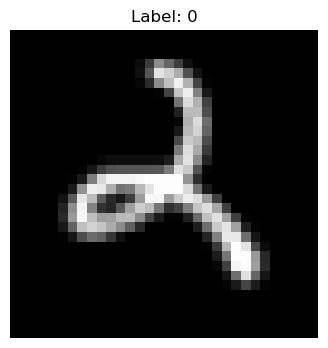

In [9]:
deterministic(config["xtra"]["seed"])

data = "Mnist"

images, labels = load_data("train", config[data]["dataset_output_dir"])

episode_sampler = EpisodeSampler(
    images=images,
    labels=labels,
    n_way=5,
    k_shot=1,
    q_query=15,
)
support_images, support_labels, query_images, query_labels, selected_classes = episode_sampler.sample_episode()

print("support_x:", support_images.shape)
print("support_y:", support_labels.shape, support_labels)
print("query_x:", query_images.shape)
print("query_y:", query_labels.shape)
print("selected_classes (reales):", selected_classes)
print("support_labels (locales):", support_labels)

print("unique query labels:", torch.unique(query_labels))

plot_image(support_images, support_labels, config[data]["dataset_output_dir"], idx=0)

### Svhn

In [10]:
deterministic(config["xtra"]["seed"])

data = "Svhn"

save_svhn_dataloaders(
    val_size=config[data]["val_size"],
    seed = config["xtra"]["seed"]
)

100%|██████████| 182M/182M [10:27<00:00, 290kB/s]  
100%|██████████| 64.3M/64.3M [04:57<00:00, 216kB/s] 


Train dataset size: 65932
Validation dataset size: 7325
Test dataset size: 26032


support_x: torch.Size([5, 3, 32, 32])
support_y: torch.Size([5]) tensor([0, 1, 2, 3, 4])
query_x: torch.Size([75, 3, 32, 32])
query_y: torch.Size([75])
selected_classes (reales): tensor([2, 6, 1, 8, 4])
support_labels (locales): tensor([0, 1, 2, 3, 4])
unique query labels: tensor([0, 1, 2, 3, 4])


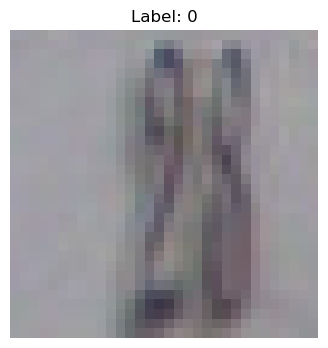

In [11]:
deterministic(config["xtra"]["seed"])

data = "Svhn"

images, labels = load_data("train", config[data]["dataset_output_dir"])

episode_sampler = EpisodeSampler(
    images=images,
    labels=labels,
    n_way=5,
    k_shot=1,
    q_query=15,
)
support_images, support_labels, query_images, query_labels, selected_classes = episode_sampler.sample_episode()

print("support_x:", support_images.shape)
print("support_y:", support_labels.shape, support_labels)
print("query_x:", query_images.shape)
print("query_y:", query_labels.shape)
print("selected_classes (reales):", selected_classes)
print("support_labels (locales):", support_labels)

print("unique query labels:", torch.unique(query_labels))

plot_image(support_images, support_labels, config[data]["dataset_output_dir"], idx=0)

### MNIST_M

In [12]:
deterministic(config["xtra"]["seed"])

data = "Mnist_M"

save_mnist_m_dataloaders(
    val_size=0.1,
    seed= config["xtra"]["seed"]
)

Train dataset size: 53101
Validation dataset size: 5900
Test dataset size: 9001
MNIST-M mean: (0.4582141637802124, 0.4622192680835724, 0.40840768814086914)
MNIST-M std: (0.2519531548023224, 0.23666314780712128, 0.2586107850074768)


support_x: torch.Size([5, 3, 32, 32])
support_y: torch.Size([5]) tensor([0, 1, 2, 3, 4])
query_x: torch.Size([75, 3, 32, 32])
query_y: torch.Size([75])
selected_classes (reales): tensor([2, 6, 1, 8, 4])
support_labels (locales): tensor([0, 1, 2, 3, 4])
unique query labels: tensor([0, 1, 2, 3, 4])


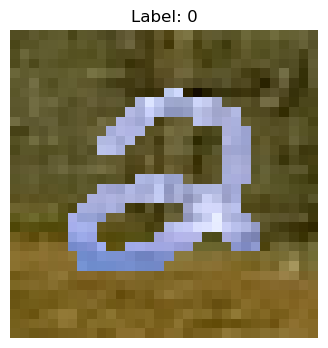

In [13]:
deterministic(config["xtra"]["seed"])

data = "Mnist_M"

images, labels = load_data("train", config[data]["dataset_output_dir"])

episode_sampler = EpisodeSampler(
    images=images,
    labels=labels,
    n_way=5,
    k_shot=1,
    q_query=15,
)
support_images, support_labels, query_images, query_labels, selected_classes = episode_sampler.sample_episode()

print("support_x:", support_images.shape)
print("support_y:", support_labels.shape, support_labels)
print("query_x:", query_images.shape)
print("query_y:", query_labels.shape)
print("selected_classes (reales):", selected_classes)
print("support_labels (locales):", support_labels)

print("unique query labels:", torch.unique(query_labels))

plot_image(support_images, support_labels, config[data]["dataset_output_dir"], idx=0)